# Robust Sentiment Analysis on Noisy Twitter Data

This notebook rebuilds the project around the original proposal requirements:

- compares **TF-IDF + Logistic Regression**, **TF-IDF + linear SVM**, **TF-IDF -> TruncatedSVD -> MLP**, and an **LSTM sequence model**
- runs a **preprocessing ablation** that compares whitespace tokenization, a library tokenizer, stemming, and lemmatization
- extends the classical comparison to include **character n-gram TF-IDF**
- reports **binary, macro, and class-wise metrics**
- evaluates models on the shared **80/10/10 split** and on a stricter **high-noise Twitter subset**
- exports reproducible tables, figures, and model artifacts to `outputs/`


In [1]:
%pip install -q -U "kagglehub[pandas-datasets]" nltk torch python-docx



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import ast
import json
import random
import re
import warnings
from collections import Counter
from pathlib import Path
from time import perf_counter

import joblib
import kagglehub
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from kagglehub import KaggleDatasetAdapter
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
from sklearn.decomposition import TruncatedSVD
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")

for resource in ["wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")


/Users/pete/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Using device: mps


In [3]:
file_path = "training.1600000.processed.noemoticon.csv"

df_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "kazanova/sentiment140",
    file_path,
    pandas_kwargs={
        "encoding": "latin-1",
        "header": None,
        "on_bad_lines": "skip",
    },
)

df = df_raw.copy()
df.columns = ["target", "id", "date", "flag", "user", "text"]
df["target"] = df["target"].replace(4, 1)
df = df[["text", "target"]].dropna().copy()
df["text"] = df["text"].astype(str)

df.head()


,text,target
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [4]:
TRAIN_FRACTION = 0.80
VALIDATION_FRACTION = 0.10
TEST_FRACTION = 0.10

analysis_df = df.copy()

train_df, holdout_df = train_test_split(
    analysis_df,
    test_size=VALIDATION_FRACTION + TEST_FRACTION,
    random_state=RANDOM_STATE,
    stratify=analysis_df["target"],
)

val_df, test_df = train_test_split(
    holdout_df,
    test_size=TEST_FRACTION / (VALIDATION_FRACTION + TEST_FRACTION),
    random_state=RANDOM_STATE,
    stratify=holdout_df["target"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "positive_rate": train_df["target"].mean()},
        {"split": "validation", "rows": len(val_df), "positive_rate": val_df["target"].mean()},
        {"split": "test", "rows": len(test_df), "positive_rate": test_df["target"].mean()},
    ]
)

split_summary


,split,rows,positive_rate
0,train,1280000,0.5
1,validation,160000,0.5
2,test,160000,0.5


## Preprocessing Ablation

The proposal promised two extra preprocessing checks that were missing from the earlier notebook:

- tokenization comparison: simple whitespace splitting vs. a library tokenizer
- stemming and lemmatization ablations

To keep this tractable, the ablation uses a stratified sample from the training and validation splits, selects the strongest variant on validation macro F1, and then applies that single chosen pipeline to the full experiment.


In [5]:
EMOTICON_PATTERNS = [
    (r"(?<!\w):-?\)(?!\w)", "smile"),
    (r"(?<!\w):-?\((?!\w)", "sad"),
    (r"(?<!\w):d(?!\w)", "laugh"),
    (r"(?<!\w)<3(?!\w)", "love"),
    (r"(?<!\w);-?\)(?!\w)", "wink"),
]

REPEATED_CHAR_PATTERN = re.compile(r"(.)\1{2,}")
URL_PATTERN = re.compile(r"http\S+|www\.\S+", re.IGNORECASE)
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")

tweet_tokenizer = TweetTokenizer(preserve_case=False, strip_handles=False, reduce_len=True)
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

PREPROCESSING_VARIANTS = [
    {
        "variant": "basic_whitespace",
        "description": "Lowercase + whitespace cleanup baseline",
        "tokenizer": "whitespace",
        "stemming": False,
        "lemmatization": False,
        "advanced_normalization": False,
    },
    {
        "variant": "advanced_whitespace",
        "description": "Advanced normalization + whitespace tokenizer",
        "tokenizer": "whitespace",
        "stemming": False,
        "lemmatization": False,
        "advanced_normalization": True,
    },
    {
        "variant": "advanced_tweet_tokenizer",
        "description": "Advanced normalization + TweetTokenizer",
        "tokenizer": "tweet",
        "stemming": False,
        "lemmatization": False,
        "advanced_normalization": True,
    },
    {
        "variant": "advanced_tweet_stem",
        "description": "Advanced normalization + TweetTokenizer + stemming",
        "tokenizer": "tweet",
        "stemming": True,
        "lemmatization": False,
        "advanced_normalization": True,
    },
    {
        "variant": "advanced_tweet_lemma",
        "description": "Advanced normalization + TweetTokenizer + lemmatization",
        "tokenizer": "tweet",
        "stemming": False,
        "lemmatization": True,
        "advanced_normalization": True,
    },
]

def replace_emoticons(text):
    updated = text
    for pattern, label in EMOTICON_PATTERNS:
        updated = re.sub(pattern, f" {label} ", updated)
    return updated

def normalize_tweet_text(text, advanced_normalization=True):
    normalized = str(text).lower()
    if advanced_normalization:
        normalized = URL_PATTERN.sub(" url ", normalized)
        normalized = MENTION_PATTERN.sub(" user ", normalized)
        normalized = HASHTAG_PATTERN.sub(r" \1 ", normalized)
        normalized = replace_emoticons(normalized)
        normalized = REPEATED_CHAR_PATTERN.sub(r"\1\1", normalized)
    normalized = re.sub(r"[^a-z\s]", " ", normalized)
    normalized = re.sub(r"\s+", " ", normalized).strip()
    return normalized

def tokenize_text(text, tokenizer_name):
    if tokenizer_name == "tweet":
        return tweet_tokenizer.tokenize(text)
    return text.split()

def apply_preprocessing_variant(text, variant_config):
    normalized = normalize_tweet_text(text, advanced_normalization=variant_config["advanced_normalization"])
    tokens = [token for token in tokenize_text(normalized, variant_config["tokenizer"]) if token]

    processed_tokens = []
    for token in tokens:
        if variant_config["stemming"]:
            token = stemmer.stem(token)
        if variant_config["lemmatization"]:
            token = lemmatizer.lemmatize(token)
        processed_tokens.append(token)

    return " ".join(processed_tokens)

def preprocess_series(series, variant_config):
    return series.astype(str).apply(lambda text: apply_preprocessing_variant(text, variant_config))


In [ ]:
PREPROCESSING_TRAIN_SAMPLE_ROWS = 200000
PREPROCESSING_VAL_SAMPLE_ROWS = 40000

def stratified_sample(frame, max_rows):
    if max_rows is None or len(frame) <= max_rows:
        return frame.reset_index(drop=True)
    sampled_frame, _ = train_test_split(
        frame,
        train_size=max_rows,
        random_state=RANDOM_STATE,
        stratify=frame["target"],
    )
    return sampled_frame.reset_index(drop=True)

ablation_train_df = stratified_sample(train_df, PREPROCESSING_TRAIN_SAMPLE_ROWS)
ablation_val_df = stratified_sample(val_df, PREPROCESSING_VAL_SAMPLE_ROWS)

preprocessing_rows = []

for variant_config in PREPROCESSING_VARIANTS:
    train_text = preprocess_series(ablation_train_df["text"], variant_config)
    val_text = preprocess_series(ablation_val_df["text"], variant_config)

    vectorizer = TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=5,
        max_features=5000,
        sublinear_tf=True,
    )

    X_train = vectorizer.fit_transform(train_text)
    X_val = vectorizer.transform(val_text)

    model = LogisticRegression(
        C=0.5,
        max_iter=1000,
        solver="liblinear",
        random_state=RANDOM_STATE,
    )

    train_start = perf_counter()
    model.fit(X_train, ablation_train_df["target"])
    train_time = perf_counter() - train_start

    val_pred = model.predict(X_val)
    val_score = model.predict_proba(X_val)[:, 1]
    report = classification_report(
        ablation_val_df["target"],
        val_pred,
        output_dict=True,
        zero_division=0,
    )

    preprocessing_rows.append(
        {
            "variant": variant_config["variant"],
            "description": variant_config["description"],
            "tokenizer": variant_config["tokenizer"],
            "stemming": variant_config["stemming"],
            "lemmatization": variant_config["lemmatization"],
            "advanced_normalization": variant_config["advanced_normalization"],
            "training_rows": len(ablation_train_df),
            "validation_rows": len(ablation_val_df),
            "train_time_sec": train_time,
            "accuracy": accuracy_score(ablation_val_df["target"], val_pred),
            "precision": precision_score(ablation_val_df["target"], val_pred, zero_division=0),
            "recall": recall_score(ablation_val_df["target"], val_pred, zero_division=0),
            "f1": f1_score(ablation_val_df["target"], val_pred, zero_division=0),
            "macro_f1": report["macro avg"]["f1-score"],
            "roc_auc": roc_auc_score(ablation_val_df["target"], val_score),
        }
    )

preprocessing_ablation_results = (
    pd.DataFrame(preprocessing_rows)
    .sort_values(["macro_f1", "roc_auc"], ascending=[False, False])
    .reset_index(drop=True)
)

selected_preprocessing = preprocessing_ablation_results.iloc[0].to_dict()
selected_variant_name = selected_preprocessing["variant"]
selected_variant_config = next(
    config for config in PREPROCESSING_VARIANTS if config["variant"] == selected_variant_name
)

preprocessing_ablation_results


,variant,description,tokenizer,stemming,lemmatization,advanced_normalization,training_rows,validation_rows,train_time_sec,accuracy,precision,recall,f1,macro_f1,roc_auc
0,advanced_tweet_stem,Advanced normalization + TweetTokenizer + stem...,tweet,True,False,True,200000,40000,0.400088,0.794275,0.789598,0.80235,0.795923,0.794262,0.871926
1,advanced_whitespace,Advanced normalization + whitespace tokenizer,whitespace,False,False,True,200000,40000,0.414621,0.790350,0.785356,0.79910,0.792169,0.790334,0.870093
2,advanced_tweet_tokenizer,Advanced normalization + TweetTokenizer,tweet,False,False,True,200000,40000,0.404902,0.790350,0.785356,0.79910,0.792169,0.790334,0.870093
3,advanced_tweet_lemma,Advanced normalization + TweetTokenizer + lemm...,tweet,False,True,True,200000,40000,0.391263,0.790125,0.784981,0.79915,0.792002,0.790108,0.869997
4,basic_whitespace,Lowercase + whitespace cleanup baseline,whitespace,False,False,False,200000,40000,0.400314,0.788025,0.783057,0.79680,0.789869,0.788009,0.867872


In [7]:
print("Selected preprocessing variant:", selected_variant_name)

train_df["processed_text"] = preprocess_series(train_df["text"], selected_variant_config)
val_df["processed_text"] = preprocess_series(val_df["text"], selected_variant_config)
test_df["processed_text"] = preprocess_series(test_df["text"], selected_variant_config)
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

train_df[["text", "processed_text"]].head()


Selected preprocessing variant: advanced_tweet_stem


,text,processed_text
0,@paisleypaisley LOL why do i get ideas so far ...,user lol whi do i get idea so far in advanc it...
1,worst headache ever,worst headach ever
2,@ewaniesciuszko i am so sad i wont see you! I...,user i am so sad i wont see you i miss you alr...
3,doesn't know how to spell conked,doesn t know how to spell conk
4,&quot;So we stand here now and no one knows us...,quot so we stand here now and no one know us a...


## Controlled Comparison Setup

The final comparison now includes:

- word and character n-gram TF-IDF baselines for Logistic Regression and linear SVM
- the earlier `TF-IDF -> TruncatedSVD -> MLP` neural baseline
- an LSTM sequence model
- binary, macro, and class-wise metrics
- reproducibility exports for preprocessing choices, validation search, and final test results


In [8]:
EMOTICON_PATTERN = re.compile(r"(:\)|:-\)|:\(|:-\(|:d|<3|;\)|;\-\))", re.IGNORECASE)
EMOJI_PATTERN = re.compile("[\U0001F300-\U0001FAFF\u2600-\u27BF]+")
SLANG_PATTERN = re.compile(
    r"\b(lol|omg|wtf|idk|smh|tbh|imo|btw|lmao|rofl|ikr|u|ur|ya|tho|gonna|wanna)\b",
    re.IGNORECASE,
)
NEGATION_PATTERN = re.compile(
    r"\b(no|not|never|can't|cannot|don't|didn't|isn't|wasn't|won't|shouldn't|couldn't)\b",
    re.IGNORECASE,
)
SARCASTIC_PATTERN = re.compile(r"\b(yeah right|as if|sure jan)\b", re.IGNORECASE)

NOISE_COLUMNS = [
    "has_url",
    "has_mention",
    "has_hashtag",
    "has_repeated_chars",
    "has_emoticon",
    "has_emoji",
    "has_slang",
]

STRONG_NOISE_COLUMNS = [
    "has_url",
    "has_hashtag",
    "has_repeated_chars",
    "has_emoticon",
    "has_emoji",
    "has_slang",
]

ERROR_TAG_COLUMNS = [
    "has_negation",
    "has_sarcasm_marker",
    "has_all_caps",
    "has_excess_punctuation",
]

NOISE_SUBSET_MIN_COUNT = 2

def add_noise_and_error_flags(frame):
    tagged = frame.copy()
    tagged["has_url"] = tagged["text"].str.contains(r"http\S+|www\.\S+", regex=True, na=False)
    tagged["has_mention"] = tagged["text"].str.contains(r"@\w+", regex=True, na=False)
    tagged["has_hashtag"] = tagged["text"].str.contains(r"#\w+", regex=True, na=False)
    tagged["has_repeated_chars"] = tagged["text"].apply(
        lambda value: bool(REPEATED_CHAR_PATTERN.search(str(value)))
    )
    tagged["has_emoticon"] = tagged["text"].apply(
        lambda value: bool(EMOTICON_PATTERN.search(str(value)))
    )
    tagged["has_emoji"] = tagged["text"].apply(
        lambda value: bool(EMOJI_PATTERN.search(str(value)))
    )
    tagged["has_slang"] = tagged["text"].apply(
        lambda value: bool(SLANG_PATTERN.search(str(value)))
    )
    tagged["noise_count"] = tagged[NOISE_COLUMNS].sum(axis=1)
    tagged["strong_noise_count"] = tagged[STRONG_NOISE_COLUMNS].sum(axis=1)
    tagged["is_noisy"] = tagged["noise_count"] > 0
    tagged["is_high_noise"] = (
        (tagged["noise_count"] >= NOISE_SUBSET_MIN_COUNT)
        & (tagged["strong_noise_count"] >= 1)
    )
    tagged["has_negation"] = tagged["text"].apply(
        lambda value: bool(NEGATION_PATTERN.search(str(value)))
    )
    tagged["has_sarcasm_marker"] = tagged["text"].apply(
        lambda value: bool(SARCASTIC_PATTERN.search(str(value)))
    )
    tagged["has_all_caps"] = tagged["text"].str.contains(r"\b[A-Z]{3,}\b", regex=True, na=False)
    tagged["has_excess_punctuation"] = tagged["text"].str.contains(r"[!?]{2,}", regex=True, na=False)
    return tagged

def summarize_metrics(y_true, y_pred, y_score):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else float("nan")
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "class_0_precision": report["0"]["precision"],
        "class_0_recall": report["0"]["recall"],
        "class_0_f1": report["0"]["f1-score"],
        "class_1_precision": report["1"]["precision"],
        "class_1_recall": report["1"]["recall"],
        "class_1_f1": report["1"]["f1-score"],
        "roc_auc": roc_auc,
    }

def parameter_count(model):
    if isinstance(model, nn.Module):
        return int(sum(parameter.numel() for parameter in model.parameters()))
    if hasattr(model, "coef_"):
        return int(model.coef_.size + model.intercept_.size)
    if hasattr(model, "coefs_"):
        return int(
            sum(arr.size for arr in model.coefs_) + sum(arr.size for arr in model.intercepts_)
        )
    return None

test_df = add_noise_and_error_flags(test_df)
any_noise_test_df = test_df[test_df["is_noisy"]].copy()
high_noise_test_df = test_df[test_df["is_high_noise"]].copy()

subset_summary = pd.DataFrame(
    [
        {
            "subset": "full_test",
            "rows": len(test_df),
            "share_of_test": 1.0,
            "definition": "All held-out test tweets",
        },
        {
            "subset": "any_noise_test",
            "rows": len(any_noise_test_df),
            "share_of_test": len(any_noise_test_df) / len(test_df),
            "definition": "At least one Twitter-specific noise marker",
        },
        {
            "subset": "high_noise_test",
            "rows": len(high_noise_test_df),
            "share_of_test": len(high_noise_test_df) / len(test_df),
            "definition": "At least two noise markers and at least one strong noise marker",
        },
    ]
)

noise_summary = (
    test_df[NOISE_COLUMNS + ["noise_count", "strong_noise_count", "is_noisy", "is_high_noise"]]
    .mean(numeric_only=True)
    .sort_values(ascending=False)
    .rename("share_of_test_set")
)

subset_summary


,subset,rows,share_of_test,definition
0,full_test,160000,1.000000,All held-out test tweets
1,any_noise_test,106942,0.668388,At least one Twitter-specific noise marker
2,high_noise_test,34445,0.215281,At least two noise markers and at least one st...


In [9]:
MAX_WORD_FEATURES = 5000
MAX_CHAR_FEATURES = 20000
MLP_MAX_TRAIN_ROWS = 200000
SEQUENCE_TUNING_MAX_ROWS = 250000
MAX_SEQUENCE_LENGTH = 32
MAX_VOCAB_SIZE = 20000

def build_vectorizer(vectorizer_config):
    return TfidfVectorizer(
        analyzer=vectorizer_config["analyzer"],
        ngram_range=vectorizer_config["ngram_range"],
        min_df=vectorizer_config["min_df"],
        max_features=vectorizer_config["max_features"],
        sublinear_tf=True,
    )

def build_feature_bundle(vectorizer_config):
    bundle = {
        "vectorizer": build_vectorizer(vectorizer_config),
        "svd": None,
    }
    if vectorizer_config.get("svd_n_components") is not None:
        bundle["svd"] = TruncatedSVD(
            n_components=vectorizer_config["svd_n_components"],
            random_state=RANDOM_STATE,
        )
    return bundle

def fit_transform_features(feature_bundle, texts):
    features = feature_bundle["vectorizer"].fit_transform(texts)
    if feature_bundle["svd"] is not None:
        return feature_bundle["svd"].fit_transform(features)
    return features

def transform_features(feature_bundle, texts):
    features = feature_bundle["vectorizer"].transform(texts)
    if feature_bundle["svd"] is not None:
        return feature_bundle["svd"].transform(features)
    return features

def sample_training_frame(frame, max_rows=None):
    if max_rows is None or len(frame) <= max_rows:
        return frame.reset_index(drop=True)
    sampled_frame, _ = train_test_split(
        frame,
        train_size=max_rows,
        random_state=RANDOM_STATE,
        stratify=frame["target"],
    )
    return sampled_frame.reset_index(drop=True)


In [10]:
class TextSequenceDataset(Dataset):
    def __init__(self, texts, targets, vocabulary, max_length):
        self.texts = list(texts)
        self.targets = list(targets)
        self.vocabulary = vocabulary
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        tokens = str(self.texts[index]).split()
        token_ids = [self.vocabulary.get(token, self.vocabulary["<unk>"]) for token in tokens[: self.max_length]]
        if not token_ids:
            token_ids = [self.vocabulary["<unk>"]]
        length = len(token_ids)
        if length < self.max_length:
            token_ids += [self.vocabulary["<pad>"]] * (self.max_length - length)
        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(self.targets[index], dtype=torch.float32),
        )

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, inputs, lengths):
        embedded = self.embedding(inputs)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden_state, _) = self.lstm(packed)
        logits = self.classifier(self.dropout(hidden_state[-1])).squeeze(1)
        return logits

def build_vocabulary(texts, max_vocab_size):
    token_counter = Counter()
    for text in texts:
        token_counter.update(str(text).split())

    most_common_tokens = [token for token, _ in token_counter.most_common(max_vocab_size - 2)]
    vocabulary = {"<pad>": 0, "<unk>": 1}
    vocabulary.update({token: index + 2 for index, token in enumerate(most_common_tokens)})
    return vocabulary

def evaluate_sequence_model(model, dataloader):
    model.eval()
    predictions = []
    scores = []
    targets = []

    with torch.no_grad():
        for inputs, lengths, labels in dataloader:
            inputs = inputs.to(DEVICE)
            lengths = lengths.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(inputs, lengths)
            probabilities = torch.sigmoid(logits)
            predictions.extend((probabilities >= 0.5).long().cpu().numpy())
            scores.extend(probabilities.cpu().numpy())
            targets.extend(labels.long().cpu().numpy())

    return np.array(targets), np.array(predictions), np.array(scores)

def train_lstm_model(train_frame, val_frame, config):
    vocabulary = build_vocabulary(train_frame["processed_text"], config["max_vocab_size"])
    train_dataset = TextSequenceDataset(
        train_frame["processed_text"],
        train_frame["target"],
        vocabulary,
        config["max_sequence_length"],
    )
    val_dataset = TextSequenceDataset(
        val_frame["processed_text"],
        val_frame["target"],
        vocabulary,
        config["max_sequence_length"],
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
    )

    model = SentimentLSTM(
        vocab_size=len(vocabulary),
        embedding_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    criterion = nn.BCEWithLogitsLoss()

    best_state = None
    best_metrics = None
    best_f1 = -1.0
    epochs_without_improvement = 0

    train_start = perf_counter()
    for epoch in range(config["max_epochs"]):
        model.train()
        for inputs, lengths, labels in train_loader:
            inputs = inputs.to(DEVICE)
            lengths = lengths.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(inputs, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        y_true, y_pred, y_score = evaluate_sequence_model(model, val_loader)
        metrics = summarize_metrics(y_true, y_pred, y_score)

        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best_metrics = metrics
            best_state = {
                "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
                "vocabulary": vocabulary,
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= config["patience"]:
            break

    train_time = perf_counter() - train_start

    model.load_state_dict(best_state["model_state_dict"])
    return model, best_state["vocabulary"], best_metrics, train_time


In [11]:
vectorizer_grid = {
    "Logistic Regression": [
        {"analyzer": "word", "ngram_range": (1, 2), "min_df": 5, "max_features": MAX_WORD_FEATURES},
        {"analyzer": "char_wb", "ngram_range": (3, 5), "min_df": 5, "max_features": MAX_CHAR_FEATURES},
    ],
    "Linear SVM": [
        {"analyzer": "word", "ngram_range": (1, 2), "min_df": 5, "max_features": MAX_WORD_FEATURES},
        {"analyzer": "char_wb", "ngram_range": (3, 5), "min_df": 5, "max_features": MAX_CHAR_FEATURES},
    ],
    "MLP Neural Baseline": [
        {
            "analyzer": "word",
            "ngram_range": (1, 2),
            "min_df": 5,
            "max_features": MAX_WORD_FEATURES,
            "svd_n_components": 300,
        }
    ],
}

model_grids = {
    "Logistic Regression": {"C": [0.5, 1.0]},
    "Linear SVM": {"C": [0.5, 1.0]},
    "MLP Neural Baseline": {
        "hidden_layer_sizes": [(128,)],
        "alpha": [1e-2, 5e-2],
        "learning_rate_init": [1e-4],
    },
}

sequence_model_grid = [
    {
        "embedding_dim": 64,
        "hidden_dim": 64,
        "dropout": 0.2,
        "learning_rate": 1e-3,
        "batch_size": 1024,
        "max_epochs": 2,
        "patience": 1,
        "max_sequence_length": MAX_SEQUENCE_LENGTH,
        "max_vocab_size": MAX_VOCAB_SIZE,
    }
]


In [12]:
validation_rows = []
best_configs = {}

def build_model(model_name, model_config):
    if model_name == "Logistic Regression":
        return LogisticRegression(
            C=model_config["C"],
            max_iter=1000,
            solver="liblinear",
            random_state=RANDOM_STATE,
        )
    if model_name == "Linear SVM":
        return LinearSVC(
            C=model_config["C"],
            dual=False,
            max_iter=5000,
            random_state=RANDOM_STATE,
        )
    if model_name == "MLP Neural Baseline":
        return MLPClassifier(
            hidden_layer_sizes=model_config["hidden_layer_sizes"],
            alpha=model_config["alpha"],
            learning_rate_init=model_config["learning_rate_init"],
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=3,
            max_iter=30,
            random_state=RANDOM_STATE,
        )
    raise ValueError(f"Unsupported model: {model_name}")

def get_scores(model, features):
    if hasattr(model, "decision_function"):
        return model.decision_function(features)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, 1]
    raise ValueError("Model must expose decision_function or predict_proba.")

for model_name, model_grid in model_grids.items():
    model_best_row = None
    max_rows = MLP_MAX_TRAIN_ROWS if model_name == "MLP Neural Baseline" else None
    model_train_df = sample_training_frame(train_df, max_rows=max_rows)

    for vectorizer_config in vectorizer_grid[model_name]:
        feature_bundle = build_feature_bundle(vectorizer_config)
        X_train = fit_transform_features(feature_bundle, model_train_df["processed_text"])
        X_val = transform_features(feature_bundle, val_df["processed_text"])

        for model_config in ParameterGrid(model_grid):
            model = build_model(model_name, model_config)

            train_start = perf_counter()
            model.fit(X_train, model_train_df["target"])
            train_time = perf_counter() - train_start

            predict_start = perf_counter()
            val_pred = model.predict(X_val)
            prediction_time = perf_counter() - predict_start

            score_start = perf_counter()
            val_score = get_scores(model, X_val)
            scoring_time = perf_counter() - score_start

            row = {
                "model": model_name,
                "stage": "validation",
                "analyzer": vectorizer_config["analyzer"],
                "ngram_range": str(vectorizer_config["ngram_range"]),
                "min_df": vectorizer_config["min_df"],
                "max_features": vectorizer_config["max_features"],
                "svd_n_components": vectorizer_config.get("svd_n_components"),
                "training_rows": len(model_train_df),
                "train_time_sec": train_time,
                "prediction_time_sec": prediction_time,
                "scoring_time_sec": scoring_time,
                "parameter_count": parameter_count(model),
            }
            row.update(model_config)
            row.update(summarize_metrics(val_df["target"], val_pred, val_score))
            validation_rows.append(row)

            if model_best_row is None or row["macro_f1"] > model_best_row["macro_f1"]:
                model_best_row = row.copy()

    best_configs[model_name] = model_best_row

sequence_train_df = sample_training_frame(train_df, max_rows=SEQUENCE_TUNING_MAX_ROWS)
sequence_val_df = val_df.copy()
sequence_best_row = None

for sequence_config in sequence_model_grid:
    sequence_model, sequence_vocab, sequence_metrics, train_time = train_lstm_model(
        sequence_train_df,
        sequence_val_df,
        sequence_config,
    )
    row = {
        "model": "LSTM Sequence Model",
        "stage": "validation",
        "analyzer": "sequence_tokens",
        "ngram_range": None,
        "min_df": None,
        "max_features": sequence_config["max_vocab_size"],
        "svd_n_components": None,
        "training_rows": len(sequence_train_df),
        "train_time_sec": train_time,
        "prediction_time_sec": None,
        "scoring_time_sec": None,
        "parameter_count": parameter_count(sequence_model),
    }
    row.update(sequence_config)
    row.update(sequence_metrics)
    validation_rows.append(row)

    if sequence_best_row is None or row["macro_f1"] > sequence_best_row["macro_f1"]:
        sequence_best_row = row.copy()

best_configs["LSTM Sequence Model"] = sequence_best_row

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values(["model", "macro_f1", "roc_auc"], ascending=[True, False, False])
    .reset_index(drop=True)
)
best_config_summary = (
    pd.DataFrame(best_configs.values())
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

best_config_summary


,model,stage,analyzer,ngram_range,min_df,max_features,svd_n_components,training_rows,train_time_sec,prediction_time_sec,...,learning_rate_init,embedding_dim,hidden_dim,dropout,learning_rate,batch_size,max_epochs,patience,max_sequence_length,max_vocab_size
0,Logistic Regression,validation,word,"(1, 2)",5.0,5000,NaN,1280000,4.844072,0.003753,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Linear SVM,validation,word,"(1, 2)",5.0,5000,NaN,1280000,5.175262,0.004112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LSTM Sequence Model,validation,sequence_tokens,None,NaN,20000,NaN,250000,53.201265,NaN,...,NaN,64.0,64.0,0.2,0.001,1024.0,2.0,1.0,32.0,20000.0
3,MLP Neural Baseline,validation,word,"(1, 2)",5.0,5000,300.0,200000,10.758545,0.080640,...,0.0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
final_models = {}
comparison_rows = []
prediction_store = {}
score_store = {}
report_store = {}
confusion_store = {}

def append_final_result(
    model_name,
    split_name,
    frame,
    y_pred,
    y_score,
    train_time,
    training_rows,
    parameter_count_value,
    prediction_time_sec,
    scoring_time_sec,
):
    metrics = summarize_metrics(frame["target"], y_pred, y_score)
    metrics.update(
        {
            "model": model_name,
            "split": split_name,
            "rows": len(frame),
            "training_rows": training_rows,
            "train_time_sec": train_time,
            "prediction_time_sec": prediction_time_sec,
            "scoring_time_sec": scoring_time_sec,
            "tweets_per_second": len(frame) / prediction_time_sec if prediction_time_sec else float("inf"),
            "parameter_count": parameter_count_value,
        }
    )
    comparison_rows.append(metrics)

for model_name, best_config in best_configs.items():
    if model_name == "LSTM Sequence Model":
        final_train_df = train_df.copy()
        final_val_df = val_df.copy()
        lstm_config = {
            "embedding_dim": int(best_config["embedding_dim"]),
            "hidden_dim": int(best_config["hidden_dim"]),
            "dropout": float(best_config["dropout"]),
            "learning_rate": float(best_config["learning_rate"]),
            "batch_size": int(best_config["batch_size"]),
            "max_epochs": int(best_config["max_epochs"]),
            "patience": int(best_config["patience"]),
            "max_sequence_length": int(best_config["max_sequence_length"]),
            "max_vocab_size": int(best_config["max_vocab_size"]),
        }

        sequence_model, sequence_vocab, _, train_time = train_lstm_model(
            final_train_df,
            final_val_df,
            lstm_config,
        )
        final_models[model_name] = {
            "model": sequence_model,
            "vocabulary": sequence_vocab,
            "config": lstm_config,
            "parameter_count": parameter_count(sequence_model),
        }

        for split_name, frame in [("full_test", test_df), ("high_noise_test", high_noise_test_df)]:
            eval_dataset = TextSequenceDataset(
                frame["processed_text"],
                frame["target"],
                sequence_vocab,
                lstm_config["max_sequence_length"],
            )
            eval_loader = DataLoader(
                eval_dataset,
                batch_size=lstm_config["batch_size"],
                shuffle=False,
                num_workers=0,
            )
            predict_start = perf_counter()
            y_true, y_pred, y_score = evaluate_sequence_model(sequence_model, eval_loader)
            prediction_time = perf_counter() - predict_start
            append_final_result(
                model_name,
                split_name,
                frame,
                y_pred,
                y_score,
                train_time,
                len(final_train_df),
                final_models[model_name]["parameter_count"],
                prediction_time,
                prediction_time,
            )
            if split_name == "full_test":
                prediction_store[model_name] = y_pred
                score_store[model_name] = y_score
                report_store[model_name] = classification_report(
                    y_true,
                    y_pred,
                    digits=4,
                    zero_division=0,
                )
                confusion_store[model_name] = confusion_matrix(y_true, y_pred)

        continue

    model_train_val_df = sample_training_frame(
        train_val_df,
        max_rows=MLP_MAX_TRAIN_ROWS if model_name == "MLP Neural Baseline" else None,
    )
    vectorizer_config = {
        "analyzer": best_config["analyzer"],
        "ngram_range": ast.literal_eval(best_config["ngram_range"])
        if isinstance(best_config["ngram_range"], str)
        else best_config["ngram_range"],
        "min_df": int(best_config["min_df"]),
        "max_features": int(best_config["max_features"]),
        "svd_n_components": None
        if pd.isna(best_config.get("svd_n_components"))
        else int(best_config["svd_n_components"]),
    }

    model_config = {
        key: best_config[key]
        for key in ["C", "hidden_layer_sizes", "alpha", "learning_rate_init"]
        if key in best_config and not pd.isna(best_config[key])
    }

    feature_bundle = build_feature_bundle(vectorizer_config)
    X_train_val = fit_transform_features(feature_bundle, model_train_val_df["processed_text"])
    model = build_model(model_name, model_config)

    train_start = perf_counter()
    model.fit(X_train_val, model_train_val_df["target"])
    train_time = perf_counter() - train_start

    final_models[model_name] = {
        "vectorizer": feature_bundle["vectorizer"],
        "svd": feature_bundle["svd"],
        "model": model,
        "config": {**vectorizer_config, **model_config},
        "parameter_count": parameter_count(model),
    }

    for split_name, frame in [("full_test", test_df), ("high_noise_test", high_noise_test_df)]:
        X_eval = transform_features(feature_bundle, frame["processed_text"])
        predict_start = perf_counter()
        y_pred = model.predict(X_eval)
        prediction_time = perf_counter() - predict_start
        score_start = perf_counter()
        y_score = get_scores(model, X_eval)
        scoring_time = perf_counter() - score_start
        append_final_result(
            model_name,
            split_name,
            frame,
            y_pred,
            y_score,
            train_time,
            len(model_train_val_df),
            final_models[model_name]["parameter_count"],
            prediction_time,
            scoring_time,
        )

        if split_name == "full_test":
            prediction_store[model_name] = y_pred
            score_store[model_name] = y_score
            report_store[model_name] = classification_report(
                frame["target"],
                y_pred,
                digits=4,
                zero_division=0,
            )
            confusion_store[model_name] = confusion_matrix(frame["target"], y_pred)

comparison_results = (
    pd.DataFrame(comparison_rows)
    .sort_values(["split", "macro_f1", "roc_auc"], ascending=[True, False, False])
    .reset_index(drop=True)
)

full_results = comparison_results[comparison_results["split"] == "full_test"].set_index("model")
high_noise_results = comparison_results[comparison_results["split"] == "high_noise_test"].set_index("model")
robustness_delta = (
    high_noise_results[
        [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "macro_f1",
            "roc_auc",
        ]
    ]
    .subtract(
        full_results[
            [
                "accuracy",
                "precision",
                "recall",
                "f1",
                "macro_f1",
                "roc_auc",
            ]
        ],
        fill_value=np.nan,
    )
    .rename(columns=lambda column: f"{column}_delta_high_noise_minus_full")
    .reset_index()
)

comparison_results[
    [
        "model",
        "split",
        "rows",
        "training_rows",
        "accuracy",
        "f1",
        "macro_f1",
        "roc_auc",
        "train_time_sec",
        "prediction_time_sec",
        "tweets_per_second",
        "parameter_count",
    ]
]


,model,split,rows,training_rows,accuracy,f1,macro_f1,roc_auc,train_time_sec,prediction_time_sec,tweets_per_second,parameter_count
0,LSTM Sequence Model,full_test,160000,1280000,0.817450,0.814926,0.817416,0.899443,231.324417,2.799240,5.715836e+04,1313345
1,Logistic Regression,full_test,160000,1440000,0.800881,0.803675,0.800841,0.881079,6.323631,0.002399,6.670488e+07,5001
2,Linear SVM,full_test,160000,1440000,0.800419,0.803821,0.800359,0.880771,5.934360,0.002282,7.012291e+07,5001
3,MLP Neural Baseline,full_test,160000,200000,0.759581,0.757513,0.759564,0.840731,10.700543,0.065216,2.453395e+06,38657
4,LSTM Sequence Model,high_noise_test,34445,1280000,0.796400,0.823114,0.791648,0.877578,231.324417,0.747592,4.607460e+04,1313345
5,Logistic Regression,high_noise_test,34445,1440000,0.777413,0.810443,0.770443,0.858335,6.323631,0.000690,4.993237e+07,5001
6,Linear SVM,high_noise_test,34445,1440000,0.777413,0.810845,0.770236,0.857971,5.934360,0.000568,6.060697e+07,5001
7,MLP Neural Baseline,high_noise_test,34445,200000,0.746059,0.784243,0.737848,0.820157,10.700543,0.012619,2.729578e+06,38657


Logistic Regression
              precision    recall  f1-score   support

           0     0.8097    0.7866    0.7980     80000
           1     0.7926    0.8151    0.8037     80000

    accuracy                         0.8009    160000
   macro avg     0.8011    0.8009    0.8008    160000
weighted avg     0.8011    0.8009    0.8008    160000

--------------------------------------------------------------------------------
Linear SVM
              precision    recall  f1-score   support

           0     0.8112    0.7831    0.7969     80000
           1     0.7903    0.8178    0.8038     80000

    accuracy                         0.8004    160000
   macro avg     0.8008    0.8004    0.8004    160000
weighted avg     0.8008    0.8004    0.8004    160000

--------------------------------------------------------------------------------
MLP Neural Baseline
              precision    recall  f1-score   support

           0     0.7552    0.7681    0.7616     80000
           1     0.7641 

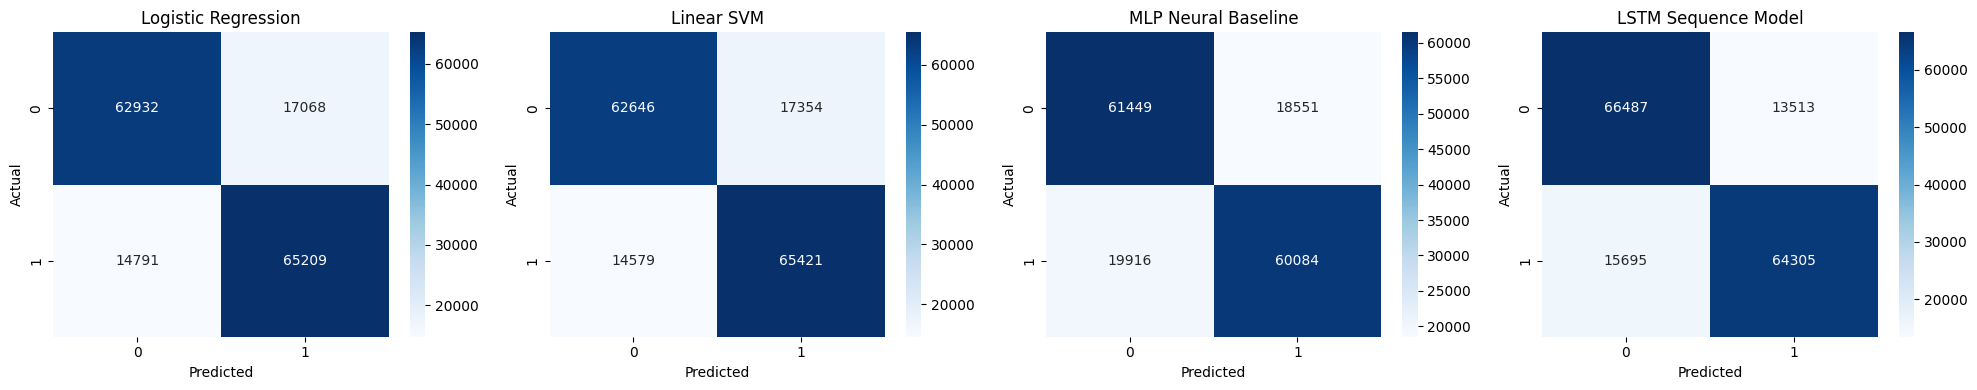

In [14]:
classwise_metrics = comparison_results[
    [
        "model",
        "split",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "class_0_precision",
        "class_0_recall",
        "class_0_f1",
        "class_1_precision",
        "class_1_recall",
        "class_1_f1",
        "roc_auc",
    ]
].copy()

for model_name, report in report_store.items():
    print(model_name)
    print(report)
    print("-" * 80)

fig, axes = plt.subplots(1, len(confusion_store), figsize=(5 * len(confusion_store), 4))
if len(confusion_store) == 1:
    axes = [axes]

for ax, (model_name, cm) in zip(axes, confusion_store.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [15]:
def build_error_table(frame, y_pred, y_score, model_name):
    error_frame = frame.copy().reset_index(drop=True)
    error_frame["prediction"] = y_pred
    error_frame["score"] = y_score
    error_frame["model"] = model_name
    error_frame["error_type"] = np.where(
        (error_frame["target"] == 0) & (error_frame["prediction"] == 1),
        "false_positive",
        np.where(
            (error_frame["target"] == 1) & (error_frame["prediction"] == 0),
            "false_negative",
            "correct",
        ),
    )
    return error_frame[error_frame["error_type"] != "correct"].copy()

error_frames = []
for model_name, y_pred in prediction_store.items():
    error_frames.append(
        build_error_table(test_df, y_pred, score_store[model_name], model_name)
    )

all_errors = pd.concat(error_frames, ignore_index=True) if error_frames else pd.DataFrame()

if not all_errors.empty:
    error_category_summary = (
        all_errors.groupby(["model", "error_type"])[NOISE_COLUMNS + ERROR_TAG_COLUMNS]
        .mean()
        .round(3)
    )

    representative_errors = (
        all_errors.assign(confidence_margin=lambda frame: np.abs(frame["score"]))
        .sort_values(["model", "confidence_margin"], ascending=[True, False])
        .groupby(["model", "error_type"])
        .head(5)
        [
            [
                "model",
                "error_type",
                "text",
                "target",
                "prediction",
                "score",
            ]
            + NOISE_COLUMNS
            + ERROR_TAG_COLUMNS
        ]
        .reset_index(drop=True)
    )

    display(error_category_summary)
    display(representative_errors)
else:
    print("No misclassifications were captured. Re-run the evaluation cells first.")


has_url  has_mention  has_hashtag  \
model               error_type                                          
LSTM Sequence Model false_negative    0.035        0.451        0.020   
                    false_positive    0.047        0.560        0.020   
Linear SVM          false_negative    0.031        0.466        0.021   
                    false_positive    0.051        0.515        0.022   
Logistic Regression false_negative    0.031        0.465        0.021   
                    false_positive    0.051        0.518        0.022   
MLP Neural Baseline false_negative    0.028        0.404        0.022   
                    false_positive    0.058        0.566        0.023   

                                    has_repeated_chars  has_emoticon  \
model               error_type                                         
LSTM Sequence Model false_negative               0.281         0.006   
                    false_positive               0.296         0.008   
Linear SVM          false_negative               0.285         0.005   
                    false_positive               0.297         0.008   
Logistic Regression false_negative               0.285         0.005   
                    false_positive               0.298         0.008   
MLP Neural Baseline false_negative               0.279         0.005   
                    false_positive               0.287         0.008   

                                    has_emoji  has_slang  has_negation  \
model               error_type                                           
LSTM Sequence Model false_negative        0.0      0.123         0.285   
                    false_positive        0.0      0.133         0.147   
Linear SVM          false_negative        0.0      0.128         0.292   
                    false_positive        0.0      0.125         0.170   
Logistic Regression false_negative        0.0      0.128         0.288   
                    false_positive        0.0      0.125         0.172   
MLP Neural Baseline false_negative        0.0      0.113         0.279   
                    false_positive        0.0      0.127         0.142   

                                    has_sarcasm_marker  has_all_caps  \
model               error_type                                         
LSTM Sequence Model false_negative               0.000         0.124   
                    false_positive               0.001         0.120   
Linear SVM          false_negative               0.000         0.123   
                    false_positive               0.001         0.115   
Logistic Regression false_negative               0.000         0.123   
                    false_positive               0.001         0.116   
MLP Neural Baseline false_negative               0.000         0.125   
                    false_positive               0.001         0.116   

                                    has_excess_punctuation  
model               error_type                              
LSTM Sequence Model false_negative                   0.093  
                    false_positive                   0.092  
Linear SVM          false_negative                   0.096  
                    false_positive                   0.090  
Logistic Regression false_negative                   0.095  
                    false_positive                   0.090  
MLP Neural Baseline false_negative                   0.094  
                    false_positive                   0.089

,model,error_type,text,target,prediction,score,has_url,has_mention,has_hashtag,has_repeated_chars,has_emoticon,has_emoji,has_slang,has_negation,has_sarcasm_marker,has_all_caps,has_excess_punctuation
0,LSTM Sequence Model,false_positive,I am finally home from my night out. It was fu...,0,1,0.997129,False,False,False,True,False,False,False,False,False,False,False
1,LSTM Sequence Model,false_positive,We will be changing our name again Please sta...,0,1,0.996818,True,False,False,False,False,False,False,False,False,False,False
2,LSTM Sequence Model,false_positive,@mileycyrus and your fans in Chile? haha Chil...,0,1,0.996765,False,True,False,False,False,False,True,False,False,False,False
3,LSTM Sequence Model,false_positive,@GothLitChic Very! I'm on rich tea biscuits G...,0,1,0.996616,False,True,False,False,False,False,False,False,False,False,False
4,LSTM Sequence Model,false_positive,is singing &quot;everlasting love&quot; http:...,0,1,0.995470,True,False,False,False,False,False,False,False,False,False,False
5,LSTM Sequence Model,false_negative,"what a gr8 day, sun is shining &amp; my exams ...",1,0,0.499992,False,False,False,False,False,False,False,False,False,False,True
6,LSTM Sequence Model,false_negative,off to the metro centre for more hair extensio...,1,0,0.499960,False,False,False,False,False,False,False,False,False,True,False
7,LSTM Sequence Model,false_negative,@misskeish I thought I was the only one who re...,1,0,0.499959,False,True,False,False,False,False,False,False,False,False,False
8,LSTM Sequence Model,false_negative,@alephdmc yaay! I'm waiting 15.00 WIB on CNBC ...,1,0,0.499913,False,True,False,False,False,False,False,False,False,True,False
9,LSTM Sequence Model,false_negative,@ltning dammit... you're right,1,0,0.499824,False,True,False,True,False,False,False,False,False,False,False


In [16]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

for existing_file in output_dir.iterdir():
    if existing_file.is_file():
        existing_file.unlink()

for model_name, bundle in final_models.items():
    artifact_prefix = model_name.lower().replace(" ", "_")
    if model_name == "LSTM Sequence Model":
        torch.save(
            {
                "model_state_dict": {
                    key: value.detach().cpu() for key, value in bundle["model"].state_dict().items()
                },
                "config": bundle["config"],
                "vocabulary": bundle["vocabulary"],
            },
            output_dir / f"{artifact_prefix}_model.pt",
        )
    else:
        joblib.dump(bundle["vectorizer"], output_dir / f"{artifact_prefix}_vectorizer.pkl")
        joblib.dump(bundle["model"], output_dir / f"{artifact_prefix}_model.pkl")
        if bundle["svd"] is not None:
            joblib.dump(bundle["svd"], output_dir / f"{artifact_prefix}_svd.pkl")

split_summary.to_csv(output_dir / "split_summary.csv", index=False)
preprocessing_ablation_results.to_csv(output_dir / "preprocessing_ablation_results.csv", index=False)
pd.DataFrame([selected_preprocessing]).to_csv(output_dir / "selected_preprocessing.csv", index=False)
subset_summary.to_csv(output_dir / "subset_summary.csv", index=False)
best_config_summary.to_csv(output_dir / "best_config_summary.csv", index=False)
validation_results.to_csv(output_dir / "validation_results.csv", index=False)
comparison_results.to_csv(output_dir / "comparison_results.csv", index=False)
classwise_metrics.to_csv(output_dir / "classwise_metrics.csv", index=False)
robustness_delta.to_csv(output_dir / "robustness_delta.csv", index=False)
noise_summary.rename_axis("feature").reset_index().to_csv(output_dir / "noise_summary.csv", index=False)

if "error_category_summary" in globals():
    error_category_summary.reset_index().to_csv(output_dir / "error_category_summary.csv", index=False)
if "representative_errors" in globals():
    representative_errors.to_csv(output_dir / "representative_errors.csv", index=False)

experiments = pd.concat(
    [
        preprocessing_ablation_results.assign(stage="preprocessing_ablation"),
        validation_results.assign(stage="validation_search"),
        comparison_results.assign(stage="final_evaluation"),
    ],
    ignore_index=True,
    sort=False,
)
experiments["run_timestamp_utc"] = pd.Timestamp.utcnow()
experiments["random_state"] = RANDOM_STATE
experiments["selected_preprocessing_variant"] = selected_variant_name
experiments["device"] = str(DEVICE)
experiments.to_csv(output_dir / "experiments.csv", index=False)

fig, axes = plt.subplots(1, len(confusion_store), figsize=(5 * len(confusion_store), 4))
if len(confusion_store) == 1:
    axes = [axes]

for ax, (model_name, cm) in zip(axes, confusion_store.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
fig.savefig(output_dir / "confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.close(fig)

delta_plot = robustness_delta.copy().set_index("model")["macro_f1_delta_high_noise_minus_full"]
fig, ax = plt.subplots(figsize=(8, 4))
delta_plot.sort_values(ascending=False).plot(kind="bar", ax=ax, color="#2a6f97")
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Macro F1 Delta")
ax.set_title("High-Noise Macro F1 Change Relative to Full Test")
plt.tight_layout()
fig.savefig(output_dir / "robustness_delta_macro_f1.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved model artifacts, figures, and result tables to outputs/.")


Saved model artifacts, figures, and result tables to outputs/.


## Final Evaluation Notes

This notebook now closes the main proposal gaps:

- the classical baselines search both **word** and **character** TF-IDF representations
- preprocessing is no longer assumed; it is selected through a documented ablation
- the exported tables include **macro** and **class-wise** metrics, not only binary summaries
- the comparison includes a true **sequence model** through the LSTM baseline
- the emoji limitation is treated honestly in the final report because Sentiment140 provides very little usable emoji coverage in this setup
